<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Mecanica-de-medios-continuos/minitarea_MCON_OceanoPlanoParalelo_Clase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mecánica de Medios Continuos
## Por Jorge I. Zuluaga
### Cuadernos de exploración numérica

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Un océano plano paralelo

Queremos en este Notebook resolver las ecuaciones de un océano plano paralelo asumiendo distintas situaciones astrofísicas. Las ecuaciones son:

$$
\begin{aligned}
& \frac{d \rho}{d z}=-\frac{\rho(z)^2 g(z)}{K(z)} \\
& \frac{d p}{d z}=-\rho g(z)
\end{aligned}
$$

## Solución ideal **incompresible**

En el caso ideal en el que se asume que el agua es incompresible, ie. $K(z)\rightarrow \infty$, la solución a estas ecuaciones es bien conocida:

$$
\rho(z) = \rho_0
$$
$$
p(z) = p_0 - \rho_0 g_0 z
$$

Supongamos que el océano es de agua y está en la Tierra:

In [ ]:
g0 = 9.8 # m/s^2
rho0 = 1000 # kg/m^3
p0 = 1.01e5 # Pa

La presión y la densidad como función de la profundidad será:

In [ ]:
zs = np.linspace(0,-11000,100)
ps_inc = p0 - rho0*g0*zs
rhos_inc = rho0*np.ones_like(ps_inc)

Un gráfico de estos campos será:

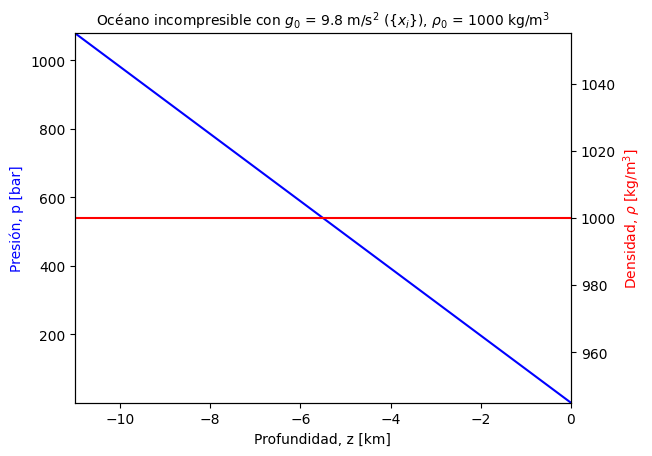

In [ ]:
fig, ax = plt.subplots(1,1)
ax.plot(zs/1e3, ps_inc/1e5, color='b')
ax.set_xlabel("Profundidad, z [km]")
ax.set_ylabel("Presión, p [bar]", color='b')

ax2 = ax.twinx()
ax2.plot(zs/1e3, rhos_inc, color = 'r')
ax2.set_ylabel(r"Densidad, $\rho$ [kg/m$^3$]",color='r')

ax.set_title(rf"Océano incompresible con $g_0$ = {g0} m/s$^2$ ({{$x_i$}}), $\rho_0$ = {rho0} kg/m$^3$",
             fontsize=10)

ax.margins(0)

## Océano **Compresible** con $g$ y $K$ constantes

Si se asume que la gravedad es constante, $g(z) = g_0$ y que el módulo de compresibilidad también lo es, $K(z) = K_0$, la solución de estas ecuaciones diferenciales produce:

$$
\rho(z) = \frac{\rho_0}{\left(1+\frac{\rho_0 g_0 z}{K_0}\right)}
$$
$$
p(z) = p_0 - K_0 \ln\left(1+\frac{\rho_0 g_0 z}{K_0}\right)
$$

**Ejercicio**: Haga un gráfico en el que muestre la variación de la presión y la densidad del agua asumiendo $K_0 = 2.21$ GPa y compárelo con la variación en la presión y densidad del caso incompresible:  

In [ ]:
K0 = 2.21e9
rhos_comp = rho0/(1+rho0*g0*zs/K0)
ps_comp = p0 - K0*np.log(1+rho0*g0*zs/K0)

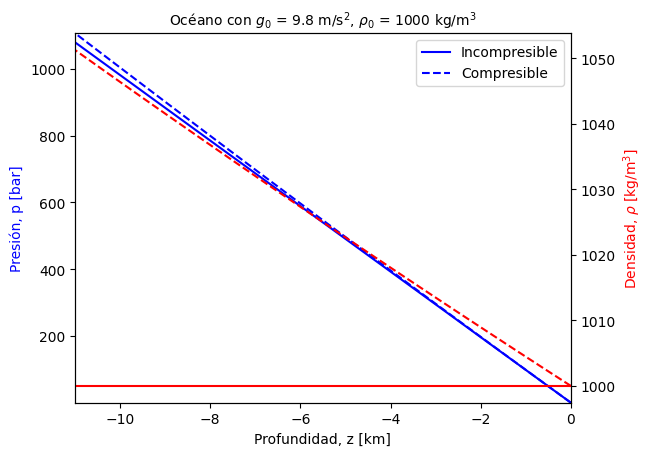

In [ ]:
fig, ax = plt.subplots(1,1)
ax.plot(zs/1e3, ps_inc/1e5, color='b', label='Incompresible')
ax.plot(zs/1e3, ps_comp/1e5, 'b--', label='Compresible')
ax.set_xlabel("Profundidad, z [km]")
ax.set_ylabel("Presión, p [bar]",color='b')
ax.legend()

ax2 = ax.twinx()
ax2.plot(zs/1e3, rhos_inc, color = 'r')
ax2.plot(zs/1e3, rhos_comp, 'r--')
ax2.set_ylabel(r"Densidad, $\rho$ [kg/m$^3$]",color='r')

ax.set_title(rf"Océano con $g_0$ = {g0} m/s$^2$, $\rho_0$ = {rho0} kg/m$^3$",
             fontsize=10)

ax.margins(0)

## **Solución numérica**

Podemos reproducir los resultados anteriores, si escribimos numéricamente las ecuaciones diferenciales:

In [ ]:
def oceano_compresible(Y,z,g=lambda z:9.8,K=lambda p:np.inf):
  rho, p = Y
  drhodz = -rho**2*g(z)/K(p)
  dpdz = -rho*g(z)
  return drhodz,dpdz

**Ejercicio**: Resuelva numéricamente con odeint el sistema de ecuaciones anterior en el caso de un oceano con compresibilidad constante $K_0$ y grafique la presión y la densidad como función de la profundidad. Comparela con el resultado anterior:

In [ ]:
# Así serían las funciones que hay que pasar a la ecuación
g = lambda z:g0
K = lambda z:K0

# Cómo son las condiciones iniciales
Y0s = [rho0,p0]

from scipy.integrate import odeint

Ys = odeint(oceano_compresible,Y0s,zs,args=(g,K))
rhos_comp_num = Ys[:,0]
ps_comp_num = Ys[:,1]

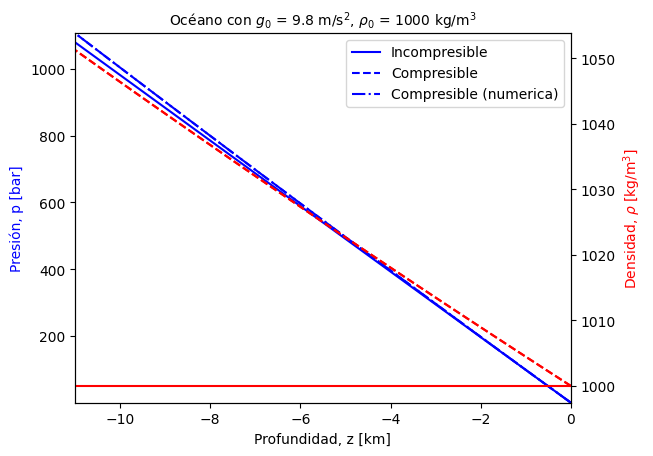

In [ ]:
fig, ax = plt.subplots(1,1)

ax.plot(zs/1e3, ps_inc/1e5, color='b',label='Incompresible')
ax.plot(zs/1e3, ps_comp/1e5, 'b--',label='Compresible')
ax.plot(zs/1e3, ps_comp_num/1e5, 'b-.',label='Compresible (numerica)')
ax.set_xlabel("Profundidad, z [km]")
ax.set_ylabel("Presión, p [bar]",color='b')
ax.legend()

ax2 = ax.twinx()
ax2.plot(zs/1e3, rhos_inc, color = 'r')
ax2.plot(zs/1e3, rhos_comp, 'r--')
ax2.plot(zs/1e3, rhos_comp_num, 'r--')
ax2.set_ylabel(r"Densidad, $\rho$ [kg/m$^3$]",color='r')

ax.set_title(rf"Océano con $g_0$ = {g0} m/s$^2$, $\rho_0$ = {rho0} kg/m$^3$",
             fontsize=10)

ax.margins(0)

## **Compresibilidad $K$ variable**

La compresibilidad del agua cambia con la presión, eso agrega una complejidad mayor al cálculo. A continuación hay una función que da la compresibilidad del agua como función de la presión:

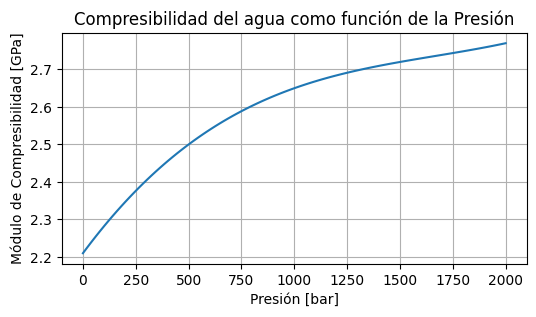

In [ ]:
def K_water(p):
  """Presion en pascales"""

  a = 8e-17
  b = -4e-8
  c = 7.6
  d = 2.21e9

  K = a*p**3 + b*p**2 + c*p + d
  return K

plt.figure(figsize = (6,3))
ps = np.linspace(0,2e8,100)
Ks = K_water(ps)
plt.plot(ps/1e5,Ks/1e9)
plt.grid()
plt.title("Compresibilidad del agua como función de la Presión")
plt.xlabel("Presión [bar]")
plt.ylabel("Módulo de Compresibilidad [GPa]")
plt.show()

Con esta ley podemos ver cómo se relaciona la presión y la densidad del agua si resolvemos la ecuación

$$
K = \rho \frac{dp}{d\rho}
$$
que se puede expresar como una ecuación diferencial así:

$$
\frac{d\rho}{dp} = \frac{\rho}{K(p)}
$$


Esta ecuación diferencial se puede implementar como una rutina en Python usando:

In [ ]:
def ecuacion_estado(rho,p,K=lambda p:np.inf):
  drhodp = rho/K(p)
  return drhodp

**Ejercicio**: Resuelva esta ecuación diferencial para encontrar la manera como la densidad del agua varía con la presión en el rango de 0 (cuando la densidad es 1000 kg/m$^3$) a 2000 bares.

In [ ]:
ps = np.linspace(1*1e5,50000*1e5,100)
Y0s = [1000]
Ys = odeint(ecuacion_estado,Y0s,ps,args=(K_water,))
rhos = Ys[:,0]

Text(0, 0.5, '$\\rho$ [kg/m3]')

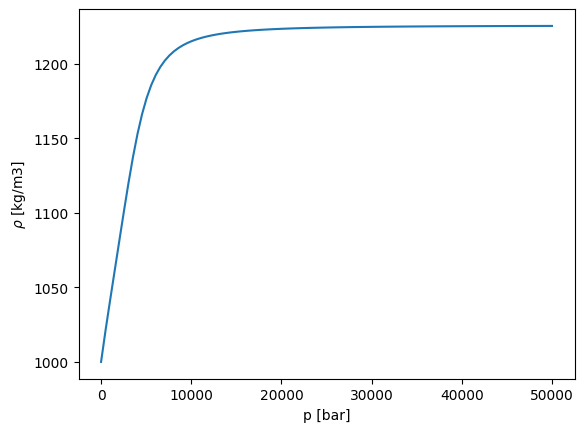

In [ ]:
plt.plot(ps/1e5, rhos)
plt.xlabel(rf"p [bar]")
plt.ylabel(rf"$\rho$ [kg/m3]")

## Océano con **compresibilidad $K$ variable**

Vamos ahora a hacer un modelo del océano con compresibilidad variable. Para ello resolveremos las ecuaciones del océano usando la rutina `K_water` que vimos antes.

**Ejercicio**: Haga un gráfico de densidad y presión como función de la profundidad del agua asumiendo compresibilidad variable del agua, y compárelo con el obtenido con el modelo incompresible y con el modelo de compresibilidad constante.

In [ ]:
# Así serían las funciones que hay que pasar a la ecuación
g = lambda z:g0
K = K_water

# Cómo son las condiciones iniciales
Y0s = [rho0, p0]

from scipy.integrate import odeint
Ys = odeint(oceano_compresible,Y0s,zs,args=(g,K))
rhos_comp_num = Ys[:,0]
ps_comp_num = Ys[:,1]

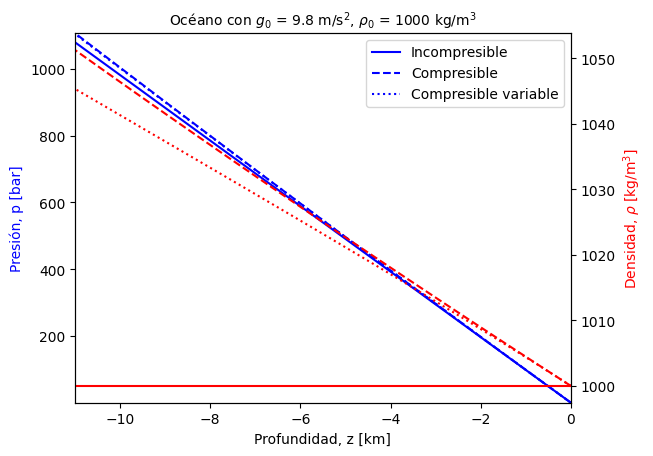

In [ ]:
fig, ax = plt.subplots(1,1)

ax.plot(zs/1e3, ps_inc/1e5, color='b',label='Incompresible')
ax.plot(zs/1e3, ps_comp/1e5, 'b--',label='Compresible')
ax.plot(zs/1e3, ps_comp_num/1e5, 'b:',label='Compresible variable')
ax.set_xlabel("Profundidad, z [km]")
ax.set_ylabel("Presión, p [bar]",color='b')
ax.legend()

ax2 = ax.twinx()
ax2.plot(zs/1e3, rhos_inc, color = 'r')
ax2.plot(zs/1e3, rhos_comp, 'r--')
ax2.plot(zs/1e3, rhos_comp_num, 'r:')
ax2.set_ylabel(r"Densidad, $\rho$ [kg/m$^3$]",color='r')

ax.set_title(rf"Océano con $g_0$ = {g0} m/s$^2$, $\rho_0$ = {rho0} kg/m$^3$",
             fontsize=10)


ax.margins(0)

## oceano con **Gravedad variable**

¿Qué pasa si ahora incluímos una dependencia de la gravedad con la altura?.  La gravedad en un planeta en función del radio y la profundidad esta dada por:

$$
g(z) = \frac{G M}{(R+z)^2}
$$
Si tomamos como referencia la gravedad superficial:

$$
g(z) = g_0 \frac{R^2}{(R+z)^2} = \frac{g_0}{(1+z/R)^2}
$$

**Ejercicio**: Usando $R=6371$ km, resuelva las ecuaciones del océano con gravedad variable y con compresibilidad variable y compárelas con los casos: compresibilidad constante-gravedad constante, compresibilidad variable-gravedad variable.

In [ ]:
R = 6371e3 # m

In [ ]:
# Así serían las funciones que hay que pasar a la ecuación
g = lambda z:g0/(1+z/R)**2
K = K_water

# Cómo son las condiciones iniciales
Y0s = [rho0,p0]

from scipy.integrate import odeint
Ys = odeint(oceano_compresible,Y0s,zs,args=(g,K))
rhos_comp_gz_num = Ys[:,0]
ps_comp_gz_num = Ys[:,1]

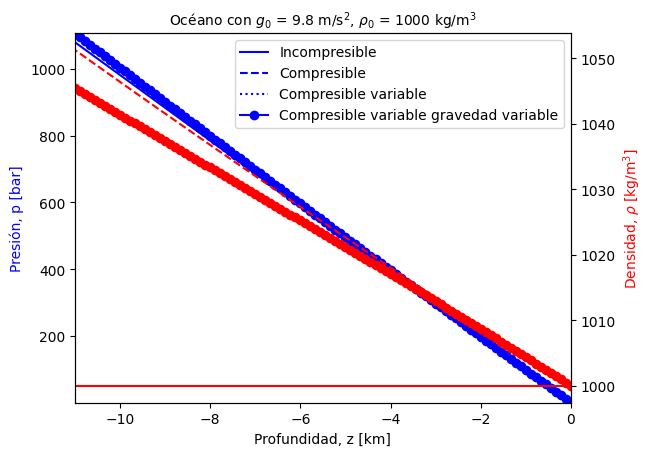

In [ ]:
fig, ax = plt.subplots(1,1)

ax.plot(zs/1e3, ps_inc/1e5, color='b',label='Incompresible')
ax.plot(zs/1e3, ps_comp/1e5, 'b--',label='Compresible')
ax.plot(zs/1e3, ps_comp_num/1e5, 'b:',label='Compresible variable')
ax.plot(zs/1e3, ps_comp_gz_num/1e5, 'bo-',label='Compresible variable gravedad variable')
ax.set_xlabel("Profundidad, z [km]")
ax.set_ylabel("Presión, p [bar]",color='b')
ax.legend()

ax2 = ax.twinx()
ax2.plot(zs/1e3, rhos_inc, color = 'r')
ax2.plot(zs/1e3, rhos_comp, 'r--')
ax2.plot(zs/1e3, rhos_comp_num, 'r:')
ax2.plot(zs/1e3, rhos_comp_gz_num, 'ro')
ax2.set_ylabel(r"Densidad, $\rho$ [kg/m$^3$]",color='r')

ax.set_title(rf"Océano con $g_0$ = {g0} m/s$^2$, $\rho_0$ = {rho0} kg/m$^3$",
             fontsize=10)

# ax.hlines(274, -10,0)

ax.margins(0)

## Estado del agua

¿Seguirá siendo el agua líquida a las presiones características del fondo de estos océanos? Para ello necesitamos el diagrama de fase del agua:

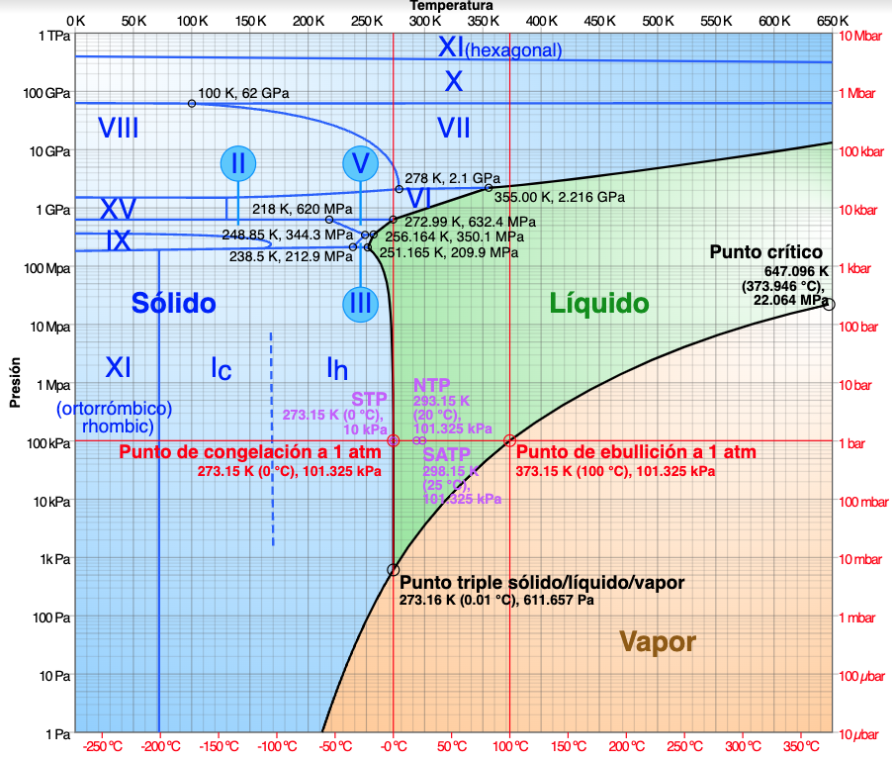

Si asumimos que la temperatura del agua es cercana a 0 C, vemos que con 620 MPa, el agua debe haber hecho una transición a Hielo VI, es decir, en el fondo de estos océanos hay hielo y no agua líquida. ¿En qué condiciones se produce esta situación?

### **Oceanos extrasolares**

Podríamos ver si un planeta con una masa mayor que la Tierra o un océano más profundo (los denominados *ocean worlds* o bien *hycean planets*) puede tener hielo en el fondo. Para ello podemos integrar las ecuaciones del oceano variando la masa o la profundidad del oceano.

**Ejercicio**: Manteniendo la máxima profundidad del océano en 10 km, aumente la masa del planeta entre 1 y 10 masas terrestres. Integre la ecuación del océano con compresibilidad variable. Para el radio del océano suponga que el radio escala con la fórmula:

$$
R = R_\oplus\left(\frac{M}{M_\oplus}\right)^{1/3}
$$

Haga un gráfico de la presión en el fondo del océano como función de la masa del planeta. ¿Se alcanza el valor crítico para la transición al hielo en alguna masa?. Aumente la profundidad del océano hasta que se alcance la condición para que haya hielo en 1 masa terrestre.

In [ ]:
Ms = np.linspace(1,10,100) # [M_terrestres]
Rs = Ms**(1/3)             # [R_terrestres]
g0_exo = g0*Ms/Rs**2       # g0 de cada exopla

Text(0, 0.5, 'p ocean bottom [bar]')

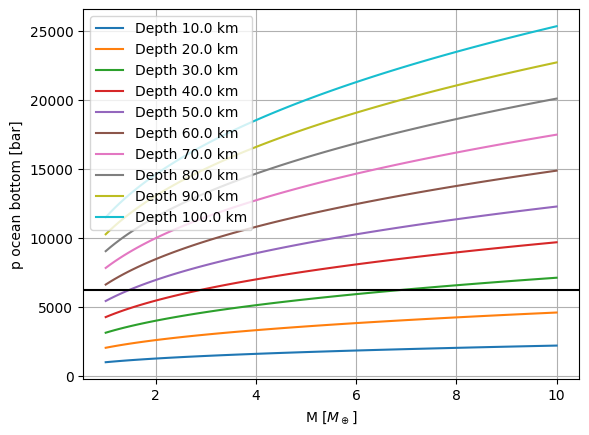

In [ ]:
for H in np.linspace(10,100,10): # en cada profundidad

  zs = np.linspace(0,-H*1e3,100) # {0,10-100K} km de profundidad
  ps_fondo = []

  for i in range(len(Ms)): # en cada exoplaneta

    # Así serían las funciones que hay que pasar a la ecuación
    g = lambda z: g0_exo[i]/(1+z/(Rs[i]*R))**2
    K = K_water

    # Cómo son las condiciones iniciales
    Y0s = [rho0,p0]

    from scipy.integrate import odeint
    Ys = odeint(oceano_compresible,Y0s,zs,args=(g,K))
    rhos_comp_gz_num = Ys[:,0]
    ps_comp_gz_num = Ys[:,1]

    ps_fondo += [ps_comp_gz_num[-1]]


  ps_fondo = np.array(ps_fondo)

  plt.plot(Ms,ps_fondo/1e5, label=f"Depth {H} km")


plt.axhline(6200,color='k')
plt.grid()
plt.legend()
plt.xlabel(r"M [$M_\oplus$]")
plt.ylabel(r"p ocean bottom [bar]")

## **Oceanos de lunas del sistema solar**

Vamos a hacer un modelo del océano interior de la Luna Europa de Júpiter. Esta Luna tiene una corteza de hielo con 20 km de espesor y se supone que la profundidad de su océano interior es de 110 km. La gravedad superficial de Europa es $g_0=1.33$ m/s$^2$ y su radio es de 1560 km.


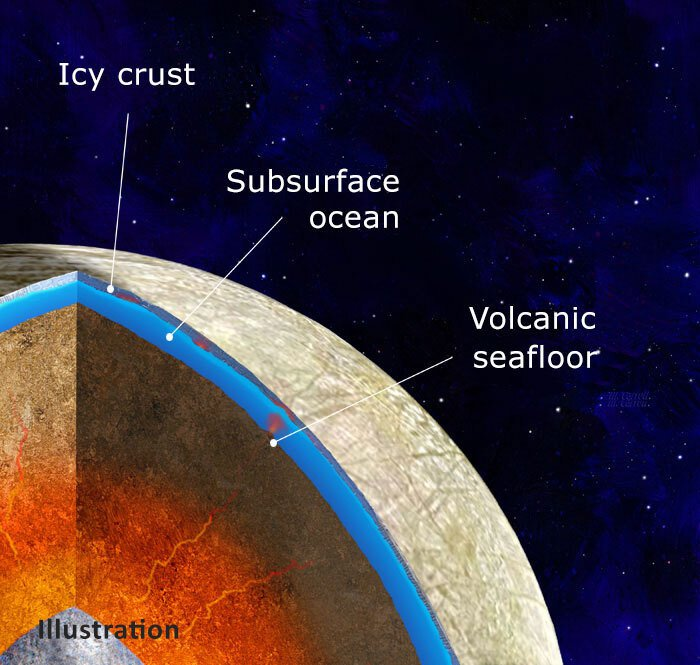


Queremos encontrar la presión en el fondo del océano. Para ello necesitamos integrar la ecuación del océano, primero para la corteza de hielo y luego para el oceano interior:

## Europa

## **Capa de Hielo Superior**

**Ejercicio E1**: Usando un modelo de gravedad variable y compresibilidad constante e igual a $K_0=10.4$ GPa (compresibilidad del hielo) calcule resolviendo las ecuaciones del océano, la presión en el fondo de la capa de hielo de Europa. ¿A qué profundidad en el oceano de la Tierra corresponde esa presión?

In [ ]:
# parametros para europa
g0_euro = 1.33    # [m/s^2]
R_euro = 1560*1e3 # [m]
K0_ice = 10.4*1e9 # [pa]

In [ ]:
zs_ice = np.linspace(0, -20*1e3, 100) # {0,-20}km

# Así serían las funciones que hay que pasar a la ecuación
g = lambda z: g0_euro/(1+z/(R_euro))**2
K = lambda p: K0_ice

# Cómo son las condiciones iniciales
rho0_euro = 0.9168*(100)**3/(1e3)  # [kg/m3] densidad deñ hielo comun
p0_euro = 0.1*1e-6                 # [pa] sacade de wiki
Y0s = [rho0_euro, p0_euro]

from scipy.integrate import odeint
Ys = odeint( oceano_compresible,Y0s, zs_ice, args=(g,K) )
rhos_comp_gz_ice = Ys[:,0]
ps_comp_gz_ice = Ys[:,1]
p_fondo_ice = ps_comp_gz_ice[-1]

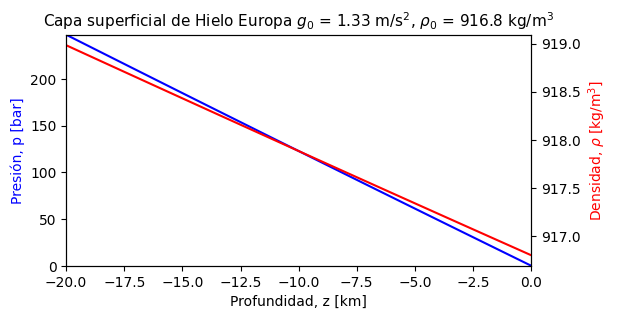


presion al final de la capa de hielo de: 247.32979063208725 [bar]


In [ ]:
fig, ax = plt.subplots(1,1, figsize=(6,3))

ax.plot(zs_ice/1e3, ps_comp_gz_ice/1e5, 'b')
ax.set_xlabel("Profundidad, z [km]")
ax.set_ylabel("Presión, p [bar]",color='b')

ax2 = ax.twinx()
ax2.plot(zs_ice/1e3, rhos_comp_gz_ice, 'r')
ax2.set_ylabel(r"Densidad, $\rho$ [kg/m$^3$]",color='r')
ax.set_title(rf"Capa superficial de Hielo Europa $g_0$ = {g0_euro} m/s$^2$, $\rho_0$ = {rho0_euro} kg/m$^3$",
             fontsize=11)
ax.margins(0)
plt.show()

print(f'\npresion al final de la capa de hielo de: {p_fondo_ice/1e5} [bar]')

Esta presion de $247.32$ [bar] al final de la capa de hielo, se encuentra en el oceano terrestre a aproximadamente $3$ km de profundidad segun los perfil de presion del oceano de la tierra.

## **Densidad inicial del Oceano interno**

Debajo de la capa de hielo, esta el agua líquida. Para encontrar el perfil de presión y densidad, necesitamos encontrar el valor inicial de la densidad del agua a la presión debajo del hielo.
para encontrar la densidad del agua a la presión debajo de la corteza de hielo de Europa.

**Ejercicio E2**: Use la ecuación de estado del agua:

In [ ]:
def ecuacion_estado(rho,p,K=lambda p:np.inf):
  drhodp = rho/K(p)
  return drhodp

In [ ]:
ps = np.linspace(1e5, p_fondo_ice, 100)
Y0s = [1000] # densidad inicial
Ys = odeint(ecuacion_estado,Y0s,ps,args=(K_water,))
rhos = Ys[:,0]
rho_fondo_ice = rhos[-1]

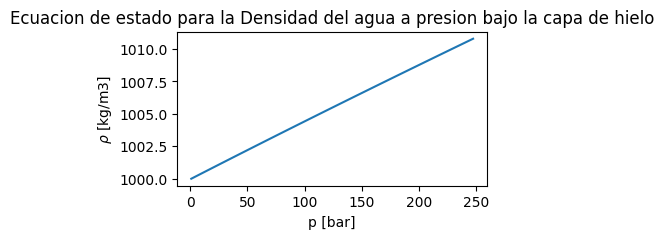


Densidad del agua bajo la capa de hielo: 1010.7887457769034 [kg/m^3]



In [ ]:
fig = plt.figure(figsize=(4,2))
plt.plot(ps/1e5, rhos)
plt.title('Ecuacion de estado para la Densidad del agua a presion bajo la capa de hielo')
plt.xlabel(rf"p [bar]")
plt.ylabel(rf"$\rho$ [kg/m3]")
plt.show()

print(f'\nDensidad del agua bajo la capa de hielo: {rho_fondo_ice} [kg/m^3]\n')

## **Perfil de Presion y Densidad del oceano de Europa**

**Ejercicio E3**: Integre la ecuación del océano para encontrar la presión en el fondo del océano de Europa y evaluar si se alcanzan las condiciones para que haya Hielo VI.

In [ ]:
zs_ocean = np.linspace(-20*1e3, -(110+20)*1e3, 100) # {-20,-130}km

# Así serían las funciones que hay que pasar a la ecuación
g = lambda z: g0_euro/(1+z/(R_euro))**2
K = K_water

# Cómo son las condiciones iniciales
rho0_ocean = rho_fondo_ice # [kg/m3]
p0_ocean = p_fondo_ice # [pa]
Y0s = [rho0_ocean, p0_ocean]

from scipy.integrate import odeint
Ys = odeint(oceano_compresible,Y0s,zs_ocean,args=(g,K))
rhos_comp_gz_ocean = Ys[:,0]
ps_comp_gz_ocean = Ys[:,1]

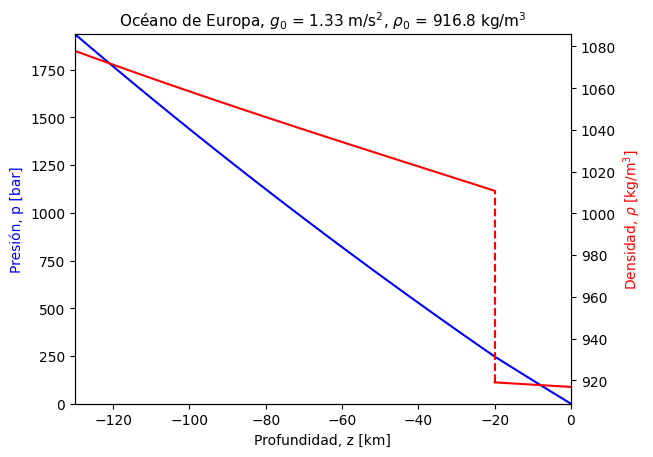


Presion en el fondo del oceano de Europa: 1935.7474046568257[bar]



In [ ]:
fig, ax = plt.subplots(1,1)

ax.plot(zs_ice/1e3, ps_comp_gz_ice/1e5, 'b')
ax.plot(zs_ocean/1e3, ps_comp_gz_ocean/1e5, 'b')
ax.set_xlabel("Profundidad, z [km]")
ax.set_ylabel("Presión, p [bar]",color='b')

ax2 = ax.twinx()
ax2.plot(zs_ocean/1e3, rhos_comp_gz_ocean, 'r')
ax2.plot(zs_ice/1e3, rhos_comp_gz_ice, 'r')
ax2.set_ylabel(r"Densidad, $\rho$ [kg/m$^3$]",color='r')

ax.set_title(rf"Océano de Europa, $g_0$ = {g0_euro} m/s$^2$, $\rho_0$ = {rho0_euro} kg/m$^3$",
             fontsize=11)
ax2.vlines(-20, rhos_comp_gz_ice[-1],rhos_comp_gz_ocean[0],'r',linestyle='--')
ax.margins(0)
plt.show()

print(f'\nPresion en el fondo del oceano de Europa: {ps_comp_gz_ocean[-1]/1e5}[bar]\n')

La presion en el fondo del oceano interno de europa $1935.7$ [bar] no supera el limite de $6200$ [bar] a partir del cual se generá el Hielo tipo IV, luego en principio en el fondo del oceano no se podria formar una capa de Hielo, por lo que las fumarolas del fondo marino si estarian en contacto con el oceano expulsando material.


Lo que coincide a primera vista con algnuos perfiles de presion de la literatura como:

*  Vance S. et al. (2008), Hydrothermal Systems in Small Ocean Planets. Recuperado de: https://www.researchgate.net/publication/5685442_Hydrothermal_Systems_in_Small_Ocean_Planets

<p align="center">
<img src= https://i.postimg.cc/C5z45NM2/europa-encelado.jpg width="900">
</p>
donde tomaron la densidad inicial de la capa de hielo como $\rho_w=1000 [kg/m^3]$

<br><br>




____

<br><br>

## Repitiendo para Ganimedes

**Ejercicio**: Repita lo anterior pero en el caso de la Luna Ganimedes: $g_0 = 1.428$ m/s$^2$, $R = 2634$ km, profundidad corteza de hielo = 150 km, profundidad océano interior = 100 km.

## **Capa de Hielo Superior**

**Ejercicio E1**: Usando un modelo de gravedad variable y compresibilidad constante e igual a $K_0=10.4$ GPa (compresibilidad del hielo) calcule resolviendo las ecuaciones del océano, la presión en el fondo de la capa de hielo de Europa. ¿A qué profundidad en el oceano de la Tierra corresponde esa presión?

In [ ]:
# parametros para ganimedes
g0_gani = 1.428   # [m/s^2]
R_gani = 2634*1e3 # [m]
K0_ice = 10.4*1e9 # [pa]

In [ ]:
zs_ice = np.linspace(0, -150*1e3, 100) # {0,-150}km

# Así serían las funciones que hay que pasar a la ecuación
g = lambda z: g0_gani/(1+z/(R_gani))**2
K = lambda p: K0_ice

# Cómo son las condiciones iniciales
rho0_gani = 0.9168*(100)**3/(1e3)  # [g/cm3] ice 0.9168
p0_gani = 0.1*1e-6                 # [pa] sacade de wiki
Y0s = [rho0_gani, p0_gani]

from scipy.integrate import odeint
Ys = odeint( oceano_compresible,Y0s, zs_ice, args=(g,K) )
rhos_comp_gz_ice = Ys[:,0]
ps_comp_gz_ice = Ys[:,1]
p_fondo_ice = ps_comp_gz_ice[-1]

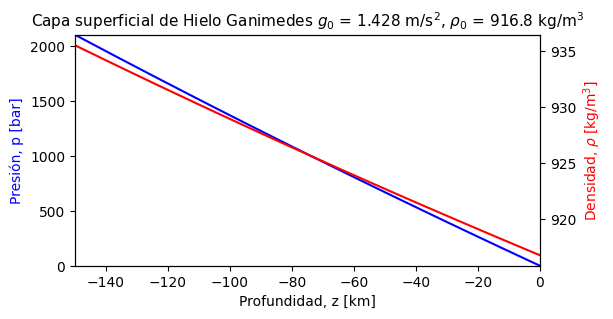


presion al final de la capa de hielo: 2103.50168071693 [bar]



In [ ]:
fig, ax = plt.subplots(1,1, figsize=(6,3))

ax.plot(zs_ice/1e3, ps_comp_gz_ice/1e5, 'b')
ax.set_xlabel("Profundidad, z [km]")
ax.set_ylabel("Presión, p [bar]",color='b')

ax2 = ax.twinx()
ax2.plot(zs_ice/1e3, rhos_comp_gz_ice, 'r')
ax2.set_ylabel(r"Densidad, $\rho$ [kg/m$^3$]",color='r')
ax.set_title(rf"Capa superficial de Hielo Ganimedes $g_0$ = {g0_gani} m/s$^2$, $\rho_0$ = {rho0_gani} kg/m$^3$",
             fontsize=11)
ax.margins(0)
plt.show()

print(f'\npresion al final de la capa de hielo: {p_fondo_ice/1e5} [bar]\n')

Esta presion al final de la capa de hielo es casi el doble que la presion en la fosa de las marianas

## **Oceano interno**

Debajo de la capa de hielo, esta el agua líquida. Para encontrar el perfil de presión y densidad, necesitamos encontrar el valor inicial de la densidad del agua a la presión debajo del hielo.
para encontrar la densidad del agua a la presión debajo de la corteza de hielo de Europa.

**Ejercicio E2**: Use la ecuación de estado del agua:

In [ ]:
def ecuacion_estado(rho,p,K=lambda p:np.inf):
  drhodp = rho/K(p)
  return drhodp

In [ ]:
ps = np.linspace(1e5, p_fondo_ice, 100)
Y0s = [1000] # densidad inicial
Ys = odeint(ecuacion_estado,Y0s,ps,args=(K_water,))
rhos = Ys[:,0]
rho_fondo_ice = rhos[-1]

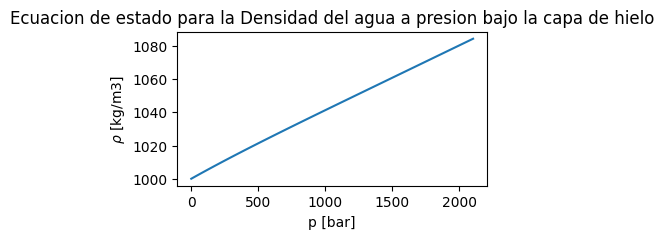


Densidad del agua bajo la capa de hielo: 1084.3521134301493 [kg/m^3]



In [ ]:
fig = plt.figure(figsize=(4,2))
plt.plot(ps/1e5, rhos)
plt.title('Ecuacion de estado para la Densidad del agua a presion bajo la capa de hielo')
plt.xlabel(rf"p [bar]")
plt.ylabel(rf"$\rho$ [kg/m3]")
plt.show()

print(f'\nDensidad del agua bajo la capa de hielo: {rho_fondo_ice} [kg/m^3]\n')

## **Perfil de Presion y Densidad del oceano de Ganimedes**

**Ejercicio E3**: Integre la ecuación del océano para encontrar la presión en el fondo del océano de ganimedes y evaluar si se alcanzan las condiciones para que haya Hielo VI.

In [ ]:
zs_ocean = np.linspace(-150*1e3, -(100+150)*1e3, 100) # {-20,-110}km

# Así serían las funciones que hay que pasar a la ecuación
g = lambda z: g0_euro/(1+z/(R_euro))**2
K = K_water

# Cómo son las condiciones iniciales
rho0_ocean = rho_fondo_ice # [kg/m3]
p0_ocean = p_fondo_ice # [pa]
Y0s = [rho0_ocean, p0_ocean]

from scipy.integrate import odeint
Ys = odeint(oceano_compresible,Y0s,zs_ocean,args=(g,K))
rhos_comp_gz_ocean = Ys[:,0]
ps_comp_gz_ocean = Ys[:,1]

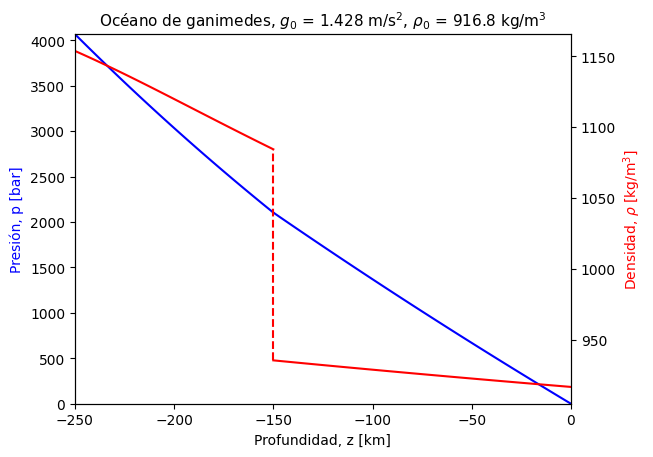


Presion en el fondo del oceano de ganimedes: 4066.8130455204578[bar]



In [ ]:
fig, ax = plt.subplots(1,1)

ax.plot(zs_ice/1e3, ps_comp_gz_ice/1e5, 'b')
ax.plot(zs_ocean/1e3, ps_comp_gz_ocean/1e5, 'b')
ax.set_xlabel("Profundidad, z [km]")
ax.set_ylabel("Presión, p [bar]",color='b')

ax2 = ax.twinx()
ax2.plot(zs_ocean/1e3, rhos_comp_gz_ocean, 'r')
ax2.plot(zs_ice/1e3, rhos_comp_gz_ice, 'r')
ax2.set_ylabel(r"Densidad, $\rho$ [kg/m$^3$]",color='r')

ax.set_title(rf"Océano de ganimedes, $g_0$ = {g0_gani} m/s$^2$, $\rho_0$ = {rho0_gani} kg/m$^3$",
             fontsize=11)
ax2.vlines(-150, rhos_comp_gz_ice[-1],rhos_comp_gz_ocean[0],'r',linestyle='--')
ax.margins(0)
plt.show()

print(f'\nPresion en el fondo del oceano de ganimedes: {ps_comp_gz_ocean[-1]/1e5}[bar]\n')

La presion en el fondo del oceano interno de ganimides $4066.8$ [bar] tampoco supera el limite de $6200$ [bar] a partir del cual se generá el Hielo tipo IV, luego en el fondo del oceano no se podria formar una capa de Hielo.

